In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [16]:
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [18]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [19]:
df["headline_length"] = df["headline"].str.len()

In [20]:
df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

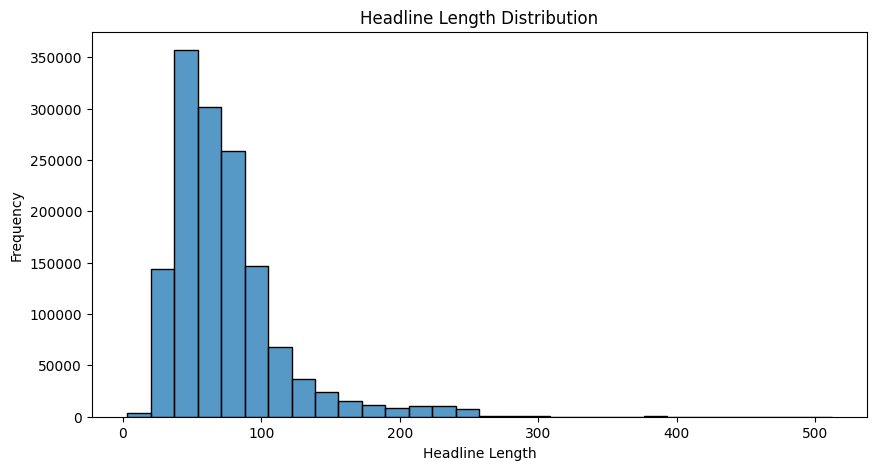

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df["headline_length"], bins=30)
plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

In [22]:
df["publisher"].value_counts()

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
MoneyGeek                 1
muathe                    1
Robert Morris             1
LeftCoastHedgie           1
Jeremie Capron            1
Name: count, Length: 1034, dtype: int64

In [23]:
top_publishers = df["publisher"].value_counts().head(10)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

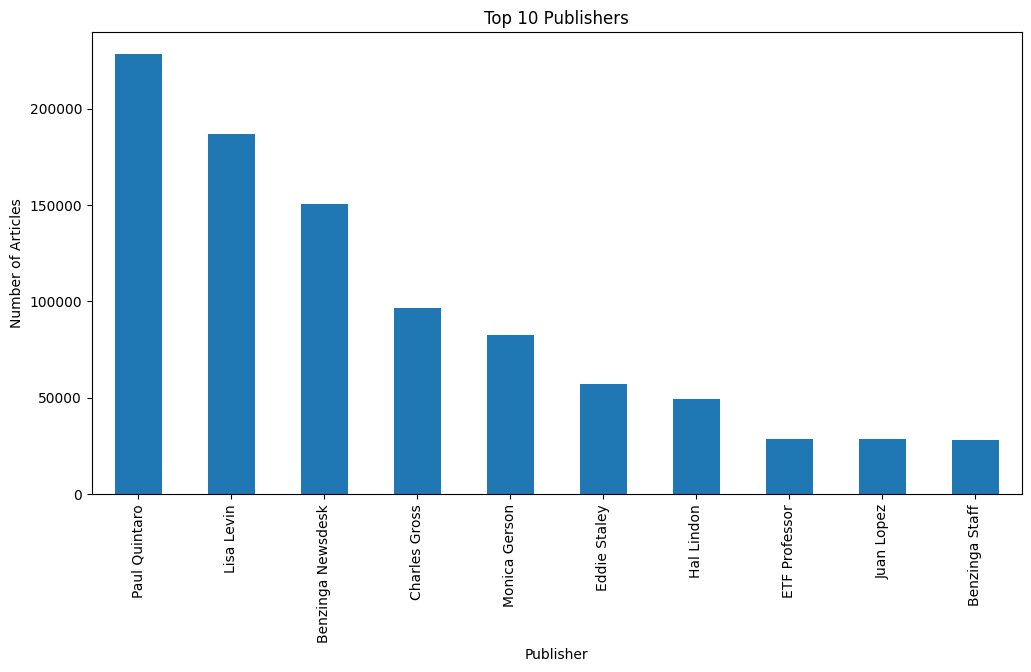

In [24]:
plt.figure(figsize=(12,6))

top_publishers.plot(kind="bar")

plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.show()

In [25]:
df["date"] = pd.to_datetime(df["date"])

ValueError: time data "2020-05-22 00:00:00" doesn't match format "%Y-%m-%d %H:%M:%S%z". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [26]:
df["date"] = pd.to_datetime(df["date"], format="mixed")

ValueError: Mixed timezones detected. Pass utc=True in to_datetime or tz='UTC' in DatetimeIndex to convert to a common timezone.

In [27]:
df["date"] = pd.to_datetime(df["date"], format="mixed", utc=True)

In [28]:
df["date"].head()

0   2020-06-05 14:30:54+00:00
1   2020-06-03 14:45:20+00:00
2   2020-05-26 08:30:07+00:00
3   2020-05-22 16:45:06+00:00
4   2020-05-22 15:38:59+00:00
Name: date, dtype: datetime64[us, UTC]

In [29]:
daily_news = df.groupby(df["date"].dt.date).size()

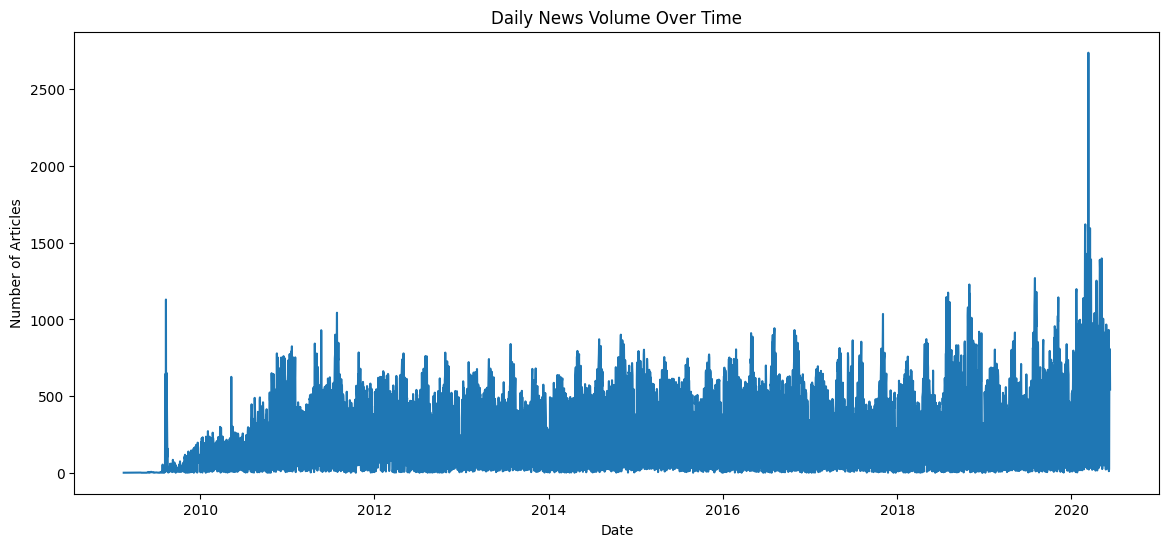

In [30]:
plt.figure(figsize=(14,6))

daily_news.plot()

plt.title("Daily News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [31]:
df["hour"] = df["date"].dt.hour

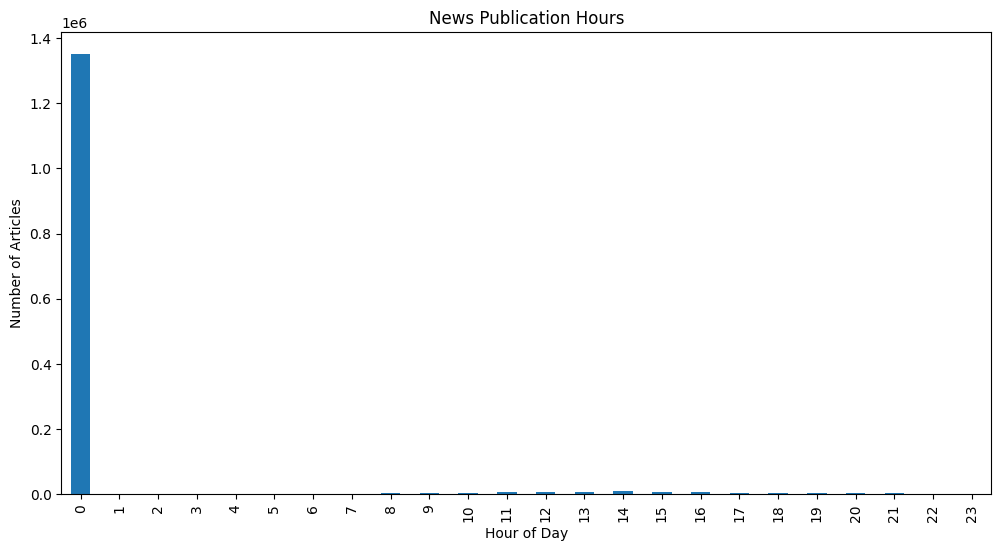

In [32]:
plt.figure(figsize=(12,6))

df["hour"].value_counts().sort_index().plot(kind="bar")

plt.title("News Publication Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")

plt.show()

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer